In [ ]:
# ============================================================
# CELL 1 — MOUNT GOOGLE DRIVE
# ============================================================

import os
from pathlib import Path

print("=" * 70)
print("NOTEBOOK 9 — OBJECT DETECTION MODEL COMPARISON")
print("=" * 70)


# ------------------------------------------------------------
# CHECK WHETHER DRIVE IS ALREADY MOUNTED
# ------------------------------------------------------------

DRIVE_ROOT = Path("/content/drive/MyDrive")

if DRIVE_ROOT.exists():

    print("\n✓ Google Drive is already mounted")

else:

    print("\nGoogle Drive is not mounted.")
    print("Mounting Google Drive...\n")

    from google.colab import drive

    drive.mount("/content/drive")


print("\nDrive root:")
print(DRIVE_ROOT)

print("\nExists:", DRIVE_ROOT.exists())

assert DRIVE_ROOT.exists(), (
    "Google Drive could not be accessed."
)


print("\n✓ ENVIRONMENT READY")

NOTEBOOK 9 — OBJECT DETECTION MODEL COMPARISON

Google Drive is not mounted.
Mounting Google Drive...

Mounted at /content/drive

Drive root:
/content/drive/MyDrive

Exists: True

✓ ENVIRONMENT READY


In [ ]:
# ============================================================
# CELL 2 — IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

from pathlib import Path
import os
import json
import time

import matplotlib.pyplot as plt


print("=" * 70)
print("IMPORTS COMPLETE")
print("=" * 70)

print("\nPandas version:", pd.__version__)
print("NumPy version:", np.__version__)

IMPORTS COMPLETE

Pandas version: 2.2.3
NumPy version: 2.1.3


In [ ]:
# ============================================================
# CELL 3 — PROJECT PATH CONFIGURATION
# ============================================================

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Image_captioning"
)


# ------------------------------------------------------------
# MODEL 1 — YOLOv5
# ------------------------------------------------------------

YOLOV5_FILE = PROJECT_ROOT / (
    "Outputs/YOLOv5_Detection/"
    "Final/yolov5_detections_full.csv"
)


# ------------------------------------------------------------
# MODEL 2 — YOLO26s
# ------------------------------------------------------------

YOLO26_FILE = PROJECT_ROOT / (
    "Outputs/YOLO26_Detection/"
    "Final/yolo26_detections_full.csv"
)


# ------------------------------------------------------------
# MODEL 3 — RT-DETR-X
# ------------------------------------------------------------

RTDETR_FILE = PROJECT_ROOT / (
    "Outputs/RTDETR_Detection/"
    "Final/rtdetr_x_detections_full.csv"
)


# ------------------------------------------------------------
# OUTPUT DIRECTORY
# ------------------------------------------------------------

OUTPUT_DIR = PROJECT_ROOT / (
    "Outputs/Model_Comparison"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


print("=" * 70)
print("MODEL FILE PATHS")
print("=" * 70)


print("\nPROJECT ROOT:")
print(PROJECT_ROOT)


print("\nYOLOv5:")
print(YOLOV5_FILE)
print("Exists:", YOLOV5_FILE.exists())


print("\nYOLO26s:")
print(YOLO26_FILE)
print("Exists:", YOLO26_FILE.exists())


print("\nRT-DETR-X:")
print(RTDETR_FILE)
print("Exists:", RTDETR_FILE.exists())


print("\nOUTPUT DIRECTORY:")
print(OUTPUT_DIR)


# ------------------------------------------------------------
# SAFETY CHECK
# ------------------------------------------------------------

assert YOLOV5_FILE.exists(), (
    "YOLOv5 final detection file not found."
)

assert YOLO26_FILE.exists(), (
    "YOLO26s final detection file not found."
)

assert RTDETR_FILE.exists(), (
    "RT-DETR-X final detection file not found."
)


print("\n" + "=" * 70)
print("✓ ALL MODEL OUTPUT FILES FOUND")
print("=" * 70)

MODEL FILE PATHS

PROJECT ROOT:
/content/drive/MyDrive/Image_captioning

YOLOv5:
/content/drive/MyDrive/Image_captioning/Outputs/YOLOv5_Detection/Final/yolov5_detections_full.csv
Exists: True

YOLO26s:
/content/drive/MyDrive/Image_captioning/Outputs/YOLO26_Detection/Final/yolo26_detections_full.csv
Exists: True

RT-DETR-X:
/content/drive/MyDrive/Image_captioning/Outputs/RTDETR_Detection/Final/rtdetr_x_detections_full.csv
Exists: True

OUTPUT DIRECTORY:
/content/drive/MyDrive/Image_captioning/Outputs/Model_Comparison

✓ ALL MODEL OUTPUT FILES FOUND


In [ ]:
# ============================================================
# CELL 4 — LOAD DETECTION RESULTS
# ============================================================

print("=" * 70)
print("LOADING MODEL OUTPUT FILES")
print("=" * 70)


print("\nLoading YOLOv5...")
yolov5_df = pd.read_csv(
    YOLOV5_FILE
)

print(
    "YOLOv5 shape:",
    yolov5_df.shape
)


print("\nLoading YOLO26s...")
yolo26_df = pd.read_csv(
    YOLO26_FILE
)

print(
    "YOLO26s shape:",
    yolo26_df.shape
)


print("\nLoading RT-DETR-X...")
rtdetr_df = pd.read_csv(
    RTDETR_FILE
)

print(
    "RT-DETR-X shape:",
    rtdetr_df.shape
)


print("\n" + "=" * 70)
print("✓ ALL MODEL OUTPUTS LOADED")
print("=" * 70)

LOADING MODEL OUTPUT FILES

Loading YOLOv5...
YOLOv5 shape: (236748, 9)

Loading YOLO26s...
YOLO26s shape: (239048, 9)

Loading RT-DETR-X...
RT-DETR-X shape: (496803, 9)

✓ ALL MODEL OUTPUTS LOADED


In [ ]:
# ============================================================
# CELL 5 — VERIFY DATA STRUCTURE
# ============================================================

print("=" * 70)
print("DATA STRUCTURE VERIFICATION")
print("=" * 70)


EXPECTED_COLUMNS = [
    "image_id",
    "image_path",
    "object_name",
    "confidence",
    "xmin",
    "ymin",
    "xmax",
    "ymax",
    "objects_detected"
]


MODEL_DATA = {
    "YOLOv5s": yolov5_df,
    "YOLO26s": yolo26_df,
    "RT-DETR-X": rtdetr_df
}


for model_name, df in MODEL_DATA.items():

    print("\n" + "-" * 70)

    print(model_name)

    print("-" * 70)

    print(
        "Columns:"
    )

    print(
        df.columns.tolist()
    )

    missing_columns = [
        col
        for col in EXPECTED_COLUMNS
        if col not in df.columns
    ]

    if missing_columns:

        print(
            "\n⚠ Missing columns:",
            missing_columns
        )

    else:

        print(
            "\n✓ All expected columns present"
        )

    print(
        "\nShape:",
        df.shape
    )

    print(
        "Unique images:",
        df["image_id"].nunique()
    )

    print(
        "Detection records:",
        len(df)
    )

    print(
        "Unique object classes:",
        df["object_name"].nunique()
    )


print("\n" + "=" * 70)
print("✓ DATA STRUCTURE CHECK COMPLETE")
print("=" * 70)

DATA STRUCTURE VERIFICATION

----------------------------------------------------------------------
YOLOv5s
----------------------------------------------------------------------
Columns:
['image_id', 'image_path', 'object_name', 'confidence', 'xmin', 'ymin', 'xmax', 'ymax', 'objects_detected']

✓ All expected columns present

Shape: (236748, 9)
Unique images: 39874
Detection records: 236748
Unique object classes: 79

----------------------------------------------------------------------
YOLO26s
----------------------------------------------------------------------
Columns:
['image_id', 'image_path', 'object_name', 'confidence', 'xmin', 'ymin', 'xmax', 'ymax', 'objects_detected']

✓ All expected columns present

Shape: (239048, 9)
Unique images: 39874
Detection records: 239048
Unique object classes: 80

----------------------------------------------------------------------
RT-DETR-X
----------------------------------------------------------------------
Columns:
['image_id', 'image_path

In [ ]:
# ============================================================
# CELL 6 — CREATE COMPLETE IMAGE UNIVERSE
# ============================================================

print("=" * 70)
print("CREATING COMPLETE IMAGE UNIVERSE")
print("=" * 70)


# ------------------------------------------------------------
# PROCESSED CAPTIONS FILE
# ------------------------------------------------------------

CAPTIONS_FILE = PROJECT_ROOT / (
    "Dataset/Processed/Captions/"
    "captions_processed.csv"
)


print("\nCaptions file:")
print(CAPTIONS_FILE)

print(
    "Exists:",
    CAPTIONS_FILE.exists()
)


assert CAPTIONS_FILE.exists(), (
    "Processed captions file not found."
)


# ------------------------------------------------------------
# LOAD ONLY IMAGE IDS
# ------------------------------------------------------------

captions_image_df = pd.read_csv(
    CAPTIONS_FILE,
    usecols=["image_id"]
)


ALL_IMAGE_IDS = sorted(
    captions_image_df[
        "image_id"
    ].dropna().unique()
)


TOTAL_IMAGES = len(
    ALL_IMAGE_IDS
)


print(
    "\nTotal unique dataset images:",
    TOTAL_IMAGES
)


print(
    "\nExpected dataset images:",
    39874
)


assert TOTAL_IMAGES == 39874, (
    f"Expected 39,874 images but found {TOTAL_IMAGES}"
)


print("\n✓ COMPLETE IMAGE UNIVERSE CREATED")

CREATING COMPLETE IMAGE UNIVERSE

Captions file:
/content/drive/MyDrive/Image_captioning/Dataset/Processed/Captions/captions_processed.csv
Exists: True

Total unique dataset images: 39874

Expected dataset images: 39874

✓ COMPLETE IMAGE UNIVERSE CREATED


In [ ]:
# ============================================================
# CELL 7 — CORRECTED CORE MODEL METRICS (SELF-CONTAINED)
# ============================================================

import pandas as pd
import numpy as np


print("=" * 70)
print("CORE MODEL METRICS — CORRECTED")
print("=" * 70)


# ------------------------------------------------------------
# BUILD COMPLETE IMAGE UNIVERSE
# ------------------------------------------------------------

all_image_ids = set()

all_image_ids.update(
    yolov5_df["image_id"]
    .dropna()
    .unique()
)

all_image_ids.update(
    yolo26_df["image_id"]
    .dropna()
    .unique()
)

all_image_ids.update(
    rtdetr_df["image_id"]
    .dropna()
    .unique()
)


# Convert to sorted list for later cells
all_image_ids = sorted(
    all_image_ids
)


TOTAL_IMAGES = len(
    all_image_ids
)


print(
    "\nTotal unique dataset images:",
    TOTAL_IMAGES
)


assert TOTAL_IMAGES == 39874, (
    f"Expected 39,874 images, "
    f"but found {TOTAL_IMAGES}"
)


# ------------------------------------------------------------
# FUNCTION: KEEP ONLY REAL DETECTIONS
# ------------------------------------------------------------

def get_actual_detections(df):

    cleaned_df = df.copy()

    # Remove missing object names
    cleaned_df = cleaned_df[
        cleaned_df["object_name"].notna()
    ].copy()


    # Convert object names to clean strings
    cleaned_df["object_name"] = (
        cleaned_df["object_name"]
        .astype(str)
        .str.strip()
    )


    # Remove invalid / placeholder values
    invalid_values = {
        "",
        "nan",
        "NaN",
        "none",
        "None",
        "null",
        "NULL"
    }


    cleaned_df = cleaned_df[
        ~cleaned_df[
            "object_name"
        ].isin(
            invalid_values
        )
    ].copy()


    return cleaned_df


# ------------------------------------------------------------
# CREATE CLEAN DETECTION DATASETS
# ------------------------------------------------------------

print("\nCleaning placeholder detection rows...")


yolov5_actual = (
    get_actual_detections(
        yolov5_df
    )
)


yolo26_actual = (
    get_actual_detections(
        yolo26_df
    )
)


rtdetr_actual = (
    get_actual_detections(
        rtdetr_df
    )
)


print(
    "\nYOLOv5 original rows:",
    len(yolov5_df)
)

print(
    "YOLOv5 actual detections:",
    len(yolov5_actual)
)


print(
    "\nYOLO26 original rows:",
    len(yolo26_df)
)

print(
    "YOLO26 actual detections:",
    len(yolo26_actual)
)


print(
    "\nRT-DETR original rows:",
    len(rtdetr_df)
)

print(
    "RT-DETR actual detections:",
    len(rtdetr_actual)
)


# ------------------------------------------------------------
# CALCULATE MODEL METRICS
# ------------------------------------------------------------

def calculate_model_metrics(
    model_name,
    actual_df
):

    detected_images = (
        actual_df[
            "image_id"
        ]
        .nunique()
    )


    zero_detection_images = (
        TOTAL_IMAGES
        - detected_images
    )


    detection_coverage = (
        detected_images
        / TOTAL_IMAGES
        * 100
    )


    zero_detection_rate = (
        zero_detection_images
        / TOTAL_IMAGES
        * 100
    )


    total_detection_records = (
        len(actual_df)
    )


    average_detections = (
        total_detection_records
        / TOTAL_IMAGES
    )


    average_confidence = (
        actual_df[
            "confidence"
        ]
        .mean()
    )


    median_confidence = (
        actual_df[
            "confidence"
        ]
        .median()
    )


    unique_classes = (
        actual_df[
            "object_name"
        ]
        .nunique()
    )


    return {

        "Model":
            model_name,

        "Total Images":
            TOTAL_IMAGES,

        "Images With Detections":
            detected_images,

        "Zero Detection Images":
            zero_detection_images,

        "Detection Coverage (%)":
            detection_coverage,

        "Zero Detection Rate (%)":
            zero_detection_rate,

        "Total Detection Records":
            total_detection_records,

        "Average Detections Per Image":
            average_detections,

        "Average Confidence":
            average_confidence,

        "Median Confidence":
            median_confidence,

        "Unique Object Classes":
            unique_classes
    }


# ------------------------------------------------------------
# BUILD COMPARISON TABLE
# ------------------------------------------------------------

comparison_metrics = []


comparison_metrics.append(
    calculate_model_metrics(
        "YOLOv5s",
        yolov5_actual
    )
)


comparison_metrics.append(
    calculate_model_metrics(
        "YOLO26s",
        yolo26_actual
    )
)


comparison_metrics.append(
    calculate_model_metrics(
        "RT-DETR-X",
        rtdetr_actual
    )
)


comparison_df = pd.DataFrame(
    comparison_metrics
)


# ------------------------------------------------------------
# ROUND DECIMAL VALUES
# ------------------------------------------------------------

decimal_columns = [

    "Detection Coverage (%)",

    "Zero Detection Rate (%)",

    "Average Detections Per Image",

    "Average Confidence",

    "Median Confidence"
]


for column in decimal_columns:

    comparison_df[column] = (
        comparison_df[column]
        .round(4)
    )


# ------------------------------------------------------------
# DISPLAY RESULTS
# ------------------------------------------------------------

print("\n")
print(
    comparison_df.to_string(
        index=False
    )
)


# ------------------------------------------------------------
# VERIFICATION
# ------------------------------------------------------------

assert (
    comparison_df[
        "Total Images"
    ].nunique()
    == 1
)


assert (
    comparison_df[
        "Total Images"
    ].iloc[0]
    == 39874
)


print("\n" + "=" * 70)
print(
    "✓ CORRECTED CORE MODEL METRICS COMPLETE"
)
print("=" * 70)

CORE MODEL METRICS — CORRECTED

Total unique dataset images: 39874

Cleaning placeholder detection rows...

YOLOv5 original rows: 236748
YOLOv5 actual detections: 236507

YOLO26 original rows: 239048
YOLO26 actual detections: 238969

RT-DETR original rows: 496803
RT-DETR actual detections: 496797


    Model  Total Images  Images With Detections  Zero Detection Images  Detection Coverage (%)  Zero Detection Rate (%)  Total Detection Records  Average Detections Per Image  Average Confidence  Median Confidence  Unique Object Classes
  YOLOv5s         39874                   39633                    241                 99.3956                   0.6044                   236507                        5.9314              0.5923             0.5968                     79
  YOLO26s         39874                   39795                     79                 99.8019                   0.1981                   238969                        5.9931              0.6327             0.6592             

In [ ]:
# ============================================================
# CELL 8 — SAVE CORE COMPARISON
# ============================================================

CORE_COMPARISON_FILE = OUTPUT_DIR / (
    "object_detection_model_comparison.csv"
)


comparison_df.to_csv(
    CORE_COMPARISON_FILE,
    index=False
)


print("=" * 70)
print("CORE COMPARISON SAVED")
print("=" * 70)


print("\nPath:")
print(CORE_COMPARISON_FILE)


print("\nFile exists:")
print(
    CORE_COMPARISON_FILE.exists()
)

CORE COMPARISON SAVED

Path:
/content/drive/MyDrive/Image_captioning/Outputs/Model_Comparison/object_detection_model_comparison.csv

File exists:
True


In [ ]:
# ============================================================
# CELL 9 — CORRECTED DETECTION DISTRIBUTION
# ============================================================

print("=" * 70)
print("DETECTION DISTRIBUTION — CORRECTED")
print("=" * 70)


# ------------------------------------------------------------
# FUNCTION TO CALCULATE DETECTIONS PER IMAGE
# ------------------------------------------------------------

def detection_distribution(
    model_name,
    actual_df
):

    # Count REAL detections for each image
    detection_counts = (
        actual_df
        .groupby("image_id")
        .size()
    )


    # Include images with ZERO detections
    full_detection_counts = (
        pd.Series(
            0,
            index=all_image_ids,
            dtype=int
        )
    )


    full_detection_counts.loc[
        detection_counts.index
    ] = detection_counts.values


    result = {

        "Model": model_name,

        "Minimum Detections":
            int(
                full_detection_counts.min()
            ),

        "Maximum Detections":
            int(
                full_detection_counts.max()
            ),

        "Mean Detections":
            float(
                full_detection_counts.mean()
            ),

        "Median Detections":
            float(
                full_detection_counts.median()
            ),

        "Images With 0 Detections":
            int(
                (full_detection_counts == 0).sum()
            ),

        "Images With 1+ Detection":
            int(
                (full_detection_counts > 0).sum()
            )
    }


    return result


# ------------------------------------------------------------
# BUILD DISTRIBUTION COMPARISON
# ------------------------------------------------------------

distribution_results = []


distribution_results.append(
    detection_distribution(
        "YOLOv5s",
        yolov5_actual
    )
)


distribution_results.append(
    detection_distribution(
        "YOLO26s",
        yolo26_actual
    )
)


distribution_results.append(
    detection_distribution(
        "RT-DETR-X",
        rtdetr_actual
    )
)


distribution_df = pd.DataFrame(
    distribution_results
)


# ------------------------------------------------------------
# ROUND MEAN VALUES
# ------------------------------------------------------------

distribution_df[
    "Mean Detections"
] = distribution_df[
    "Mean Detections"
].round(4)


print("\n")
print(
    distribution_df.to_string(
        index=False
    )
)


print("\n" + "=" * 70)
print("✓ CORRECTED DETECTION DISTRIBUTION COMPLETE")
print("=" * 70)

DETECTION DISTRIBUTION — CORRECTED


    Model  Minimum Detections  Maximum Detections  Mean Detections  Median Detections  Images With 0 Detections  Images With 1+ Detection
  YOLOv5s                   0                  57           5.9314                4.0                       241                     39633
  YOLO26s                   0                  53           5.9931                4.0                        79                     39795
RT-DETR-X                   0                 133          12.4592                7.0                         6                     39868

✓ CORRECTED DETECTION DISTRIBUTION COMPLETE


In [ ]:
# ============================================================
# CELL 10 — OBJECT CLASS FREQUENCY ANALYSIS
# ============================================================

print("=" * 70)
print("TOP DETECTED OBJECT CLASSES")
print("=" * 70)


TOP_OBJECTS = 20


for model_name, df in MODEL_DATA.items():

    print("\n" + "=" * 70)

    print(
        model_name
    )

    print("=" * 70)


    object_counts = (
        df["object_name"]
        .value_counts()
        .head(TOP_OBJECTS)
    )


    display(
        object_counts
        .rename_axis(
            "object_name"
        )
        .reset_index(
            name="detections"
        )
    )

TOP DETECTED OBJECT CLASSES

YOLOv5s


,object_name,detections
0,person,151106
1,car,9201
2,chair,8948
3,handbag,5637
4,dog,5363
5,bottle,4099
6,cup,3324
7,bicycle,3323
8,backpack,3131
9,sports ball,2471



YOLO26s


,object_name,detections
0,person,149811
1,chair,9809
2,car,9740
3,handbag,6592
4,dog,6188
5,bottle,4260
6,cup,3486
7,bicycle,3481
8,backpack,3195
9,umbrella,2383



RT-DETR-X


,object_name,detections
0,person,244674
1,chair,28747
2,handbag,23306
3,car,19865
4,backpack,12001
5,bottle,11484
6,book,10210
7,cup,8975
8,dining table,7897
9,bench,7880


In [ ]:
# ============================================================
# CELL 11 — OBJECT CLASS DIVERSITY COMPARISON
# ============================================================

print("=" * 70)
print("OBJECT CLASS DIVERSITY")
print("=" * 70)


class_sets = {}


for model_name, df in MODEL_DATA.items():

    class_sets[model_name] = set(

        df["object_name"]
        .dropna()
        .unique()
    )


all_classes = sorted(

    set.union(
        *class_sets.values()
    )
)


print(
    "\nTotal unique classes detected by at least one model:",
    len(all_classes)
)


class_comparison_records = []


for object_class in all_classes:

    record = {

        "object_name":
            object_class
    }


    for model_name in MODEL_DATA.keys():

        record[model_name] = (

            object_class
            in class_sets[model_name]

        )


    class_comparison_records.append(
        record
    )


class_comparison_df = pd.DataFrame(
    class_comparison_records
)


display(
    class_comparison_df.head(20)
)


CLASS_COMPARISON_FILE = OUTPUT_DIR / (
    "object_class_availability_comparison.csv"
)


class_comparison_df.to_csv(
    CLASS_COMPARISON_FILE,
    index=False
)


print(
    "\n✓ Object class comparison saved"
)

OBJECT CLASS DIVERSITY

Total unique classes detected by at least one model: 80


,object_name,YOLOv5s,YOLO26s,RT-DETR-X
0,airplane,True,True,True
1,apple,True,True,True
2,backpack,True,True,True
3,banana,True,True,True
4,baseball bat,True,True,True
5,baseball glove,True,True,True
6,bear,True,True,True
7,bed,True,True,True
8,bench,True,True,True
9,bicycle,True,True,True



✓ Object class comparison saved


In [ ]:
# ============================================================
# CELL 12 — CORRECTED IMAGE-LEVEL DETECTION AGREEMENT
# ============================================================

print("=" * 70)
print("IMAGE-LEVEL DETECTION AGREEMENT — CORRECTED")
print("=" * 70)


# ------------------------------------------------------------
# CREATE SETS OF IMAGES WITH REAL DETECTIONS
# ------------------------------------------------------------

yolov5_detected_images = set(
    yolov5_actual[
        "image_id"
    ].unique()
)


yolo26_detected_images = set(
    yolo26_actual[
        "image_id"
    ].unique()
)


rtdetr_detected_images = set(
    rtdetr_actual[
        "image_id"
    ].unique()
)


# ------------------------------------------------------------
# DETECTED BY ALL THREE
# ------------------------------------------------------------

all_three = (
    yolov5_detected_images
    & yolo26_detected_images
    & rtdetr_detected_images
)


# ------------------------------------------------------------
# DETECTED BY ONLY TWO MODELS
# ------------------------------------------------------------

yolov5_yolo26_only = (
    yolov5_detected_images
    & yolo26_detected_images
    - rtdetr_detected_images
)


yolov5_rtdetr_only = (
    yolov5_detected_images
    & rtdetr_detected_images
    - yolo26_detected_images
)


yolo26_rtdetr_only = (
    yolo26_detected_images
    & rtdetr_detected_images
    - yolov5_detected_images
)


# ------------------------------------------------------------
# DETECTED BY ONLY ONE MODEL
# ------------------------------------------------------------

yolov5_only = (
    yolov5_detected_images
    - yolo26_detected_images
    - rtdetr_detected_images
)


yolo26_only = (
    yolo26_detected_images
    - yolov5_detected_images
    - rtdetr_detected_images
)


rtdetr_only = (
    rtdetr_detected_images
    - yolov5_detected_images
    - yolo26_detected_images
)


# ------------------------------------------------------------
# DETECTED BY NONE
# ------------------------------------------------------------

detected_by_any = (
    yolov5_detected_images
    | yolo26_detected_images
    | rtdetr_detected_images
)


detected_by_none = (
    set(all_image_ids)
    - detected_by_any
)


# ------------------------------------------------------------
# CREATE AGREEMENT TABLE
# ------------------------------------------------------------

agreement_results = [

    {
        "Category":
            "Detected by all three models",

        "Image Count":
            len(all_three)
    },

    {
        "Category":
            "Detected by YOLOv5s + YOLO26s only",

        "Image Count":
            len(yolov5_yolo26_only)
    },

    {
        "Category":
            "Detected by YOLOv5s + RT-DETR-X only",

        "Image Count":
            len(yolov5_rtdetr_only)
    },

    {
        "Category":
            "Detected by YOLO26s + RT-DETR-X only",

        "Image Count":
            len(yolo26_rtdetr_only)
    },

    {
        "Category":
            "Detected only by YOLOv5s",

        "Image Count":
            len(yolov5_only)
    },

    {
        "Category":
            "Detected only by YOLO26s",

        "Image Count":
            len(yolo26_only)
    },

    {
        "Category":
            "Detected only by RT-DETR-X",

        "Image Count":
            len(rtdetr_only)
    },

    {
        "Category":
            "Detected by none",

        "Image Count":
            len(detected_by_none)
    }
]


agreement_df = pd.DataFrame(
    agreement_results
)


agreement_df[
    "Percentage (%)"
] = (
    agreement_df[
        "Image Count"
    ]
    / TOTAL_IMAGES
    * 100
).round(4)


print("\n")
print(
    agreement_df.to_string(
        index=False
    )
)


# ------------------------------------------------------------
# VERIFICATION
# ------------------------------------------------------------

assert (
    agreement_df[
        "Image Count"
    ].sum()
    == TOTAL_IMAGES
), "Agreement counts do not add up correctly."


print("\n" + "=" * 70)
print("✓ CORRECTED IMAGE AGREEMENT COMPLETE")
print("=" * 70)

IMAGE-LEVEL DETECTION AGREEMENT — CORRECTED


                            Category  Image Count  Percentage (%)
        Detected by all three models        39586         99.2777
  Detected by YOLOv5s + YOLO26s only            4          0.0100
Detected by YOLOv5s + RT-DETR-X only           43          0.1078
Detected by YOLO26s + RT-DETR-X only          205          0.5141
            Detected only by YOLOv5s            0          0.0000
            Detected only by YOLO26s            0          0.0000
          Detected only by RT-DETR-X           34          0.0853
                    Detected by none            2          0.0050

✓ CORRECTED IMAGE AGREEMENT COMPLETE


In [ ]:
# ============================================================
# CELL 13 — OBJECT TOKEN RICHNESS FOR IMAGE CAPTIONING
# ============================================================

print("=" * 70)
print("OBJECT TOKEN RICHNESS FOR IMAGE CAPTIONING")
print("=" * 70)


caption_feature_records = []


for model_name, df in MODEL_DATA.items():

    # --------------------------------------------------------
    # UNIQUE OBJECTS PER IMAGE
    # --------------------------------------------------------

    unique_objects_per_image = (

        df.groupby(
            "image_id"
        )["object_name"]

        .nunique()

        .reindex(
            ALL_IMAGE_IDS,
            fill_value=0
        )
    )


    # --------------------------------------------------------
    # TOTAL OBJECT TOKENS
    # --------------------------------------------------------

    total_object_tokens = (

        df["object_name"]
        .dropna()
        .shape[0]

    )


    caption_feature_records.append({

        "model":
            model_name,

        "average_unique_objects_per_image":
            unique_objects_per_image.mean(),

        "median_unique_objects_per_image":
            unique_objects_per_image.median(),

        "maximum_unique_objects_per_image":
            unique_objects_per_image.max(),

        "images_with_no_object_tokens":
            int(
                (
                    unique_objects_per_image
                    == 0
                ).sum()
            ),

        "total_object_tokens":
            total_object_tokens

    })


caption_feature_df = pd.DataFrame(
    caption_feature_records
)


display(
    caption_feature_df
)


CAPTION_FEATURE_FILE = OUTPUT_DIR / (
    "captioning_object_feature_richness.csv"
)


caption_feature_df.to_csv(
    CAPTION_FEATURE_FILE,
    index=False
)


print(
    "\n✓ Captioning-oriented object feature analysis complete"
)

OBJECT TOKEN RICHNESS FOR IMAGE CAPTIONING


,model,average_unique_objects_per_image,median_unique_objects_per_image,maximum_unique_objects_per_image,images_with_no_object_tokens,total_object_tokens
0,YOLOv5s,2.224407,2.0,12,241,236507
1,YOLO26s,2.220645,2.0,12,79,238969
2,RT-DETR-X,3.239530,3.0,18,6,496797



✓ Captioning-oriented object feature analysis complete


In [ ]:
# ============================================================
# CELL 14 — EXPERIMENTAL MODEL RANKING
# ============================================================

print("=" * 70)
print("EXPERIMENTAL MODEL RANKING")
print("=" * 70)


ranking_df = comparison_df.copy()


# ------------------------------------------------------------
# RANK 1 — DETECTION COVERAGE
# Higher coverage = better
# ------------------------------------------------------------

ranking_df["Coverage Rank"] = (
    ranking_df[
        "Detection Coverage (%)"
    ]
    .rank(
        ascending=False,
        method="min"
    )
)


# ------------------------------------------------------------
# RANK 2 — OBJECT CLASS DIVERSITY
# More classes = richer semantic information
# ------------------------------------------------------------

ranking_df["Object Class Rank"] = (
    ranking_df[
        "Unique Object Classes"
    ]
    .rank(
        ascending=False,
        method="min"
    )
)


# ------------------------------------------------------------
# RANK 3 — DETECTION RICHNESS
# More detections per image = richer object information
# ------------------------------------------------------------

ranking_df["Detection Richness Rank"] = (
    ranking_df[
        "Average Detections Per Image"
    ]
    .rank(
        ascending=False,
        method="min"
    )
)


# ------------------------------------------------------------
# COMBINED AVERAGE RANK
# ------------------------------------------------------------

ranking_df["Average Rank Score"] = (
    ranking_df[
        [
            "Coverage Rank",
            "Object Class Rank",
            "Detection Richness Rank"
        ]
    ]
    .mean(
        axis=1
    )
)


# ------------------------------------------------------------
# SORT
# ------------------------------------------------------------

ranking_df = (
    ranking_df
    .sort_values(
        by="Average Rank Score",
        ascending=True
    )
    .reset_index(
        drop=True
    )
)


# ------------------------------------------------------------
# FINAL RANK
# ------------------------------------------------------------

ranking_df.insert(
    1,
    "Final Rank",
    range(
        1,
        len(ranking_df) + 1
    )
)


display(
    ranking_df
)


# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------

FINAL_RANKING_FILE = (
    OUTPUT_DIR
    / "experimental_model_ranking.csv"
)


ranking_df.to_csv(
    FINAL_RANKING_FILE,
    index=False
)


print(
    "\n✓ Experimental ranking complete"
)


print(
    "\nIMPORTANT:"
)


print(
    "This ranking compares experimental dataset "
    "output characteristics."
)


print(
    "It must NOT be described as official "
    "object detection accuracy."
)

EXPERIMENTAL MODEL RANKING


,Model,Final Rank,Total Images,Images With Detections,Zero Detection Images,Detection Coverage (%),Zero Detection Rate (%),Total Detection Records,Average Detections Per Image,Average Confidence,Median Confidence,Unique Object Classes,Coverage Rank,Object Class Rank,Detection Richness Rank,Average Rank Score
0,RT-DETR-X,1,39874,39868,6,99.9850,0.0150,496797,12.4592,0.5215,0.4231,80,1.0,1.0,1.0,1.000000
1,YOLO26s,2,39874,39795,79,99.8019,0.1981,238969,5.9931,0.6327,0.6592,80,2.0,1.0,2.0,1.666667
2,YOLOv5s,3,39874,39633,241,99.3956,0.6044,236507,5.9314,0.5923,0.5968,79,3.0,3.0,3.0,3.000000



✓ Experimental ranking complete

IMPORTANT:
This ranking compares experimental dataset output characteristics.
It must NOT be described as official object detection accuracy.


MODEL COMPARISON VISUALIZATION

Available columns:
['Model', 'Total Images', 'Images With Detections', 'Zero Detection Images', 'Detection Coverage (%)', 'Zero Detection Rate (%)', 'Total Detection Records', 'Average Detections Per Image', 'Average Confidence', 'Median Confidence', 'Unique Object Classes']


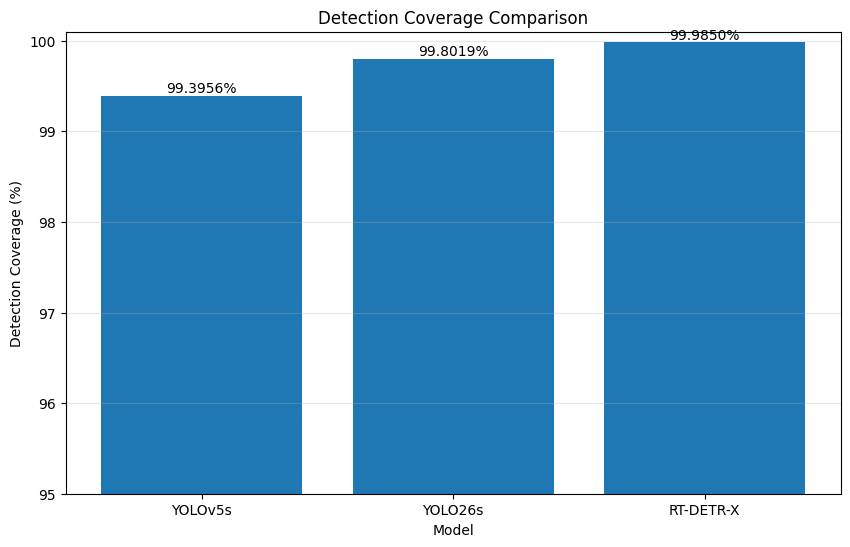

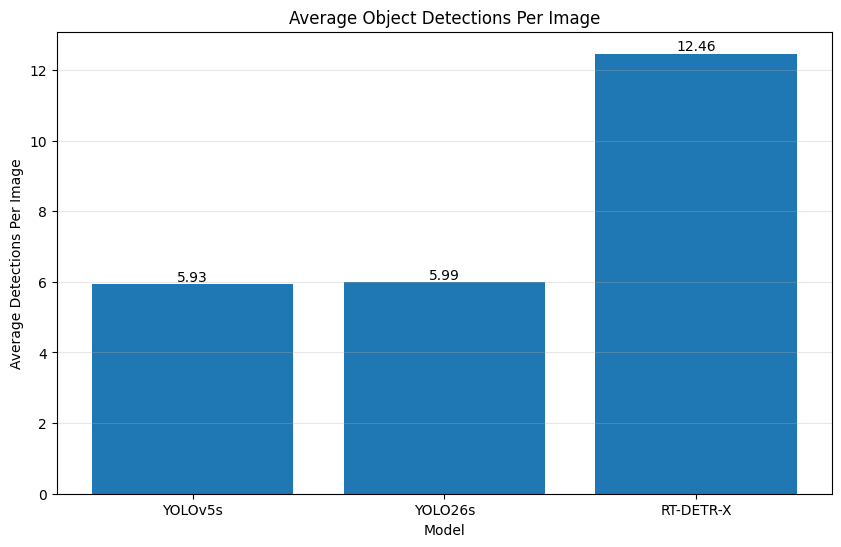

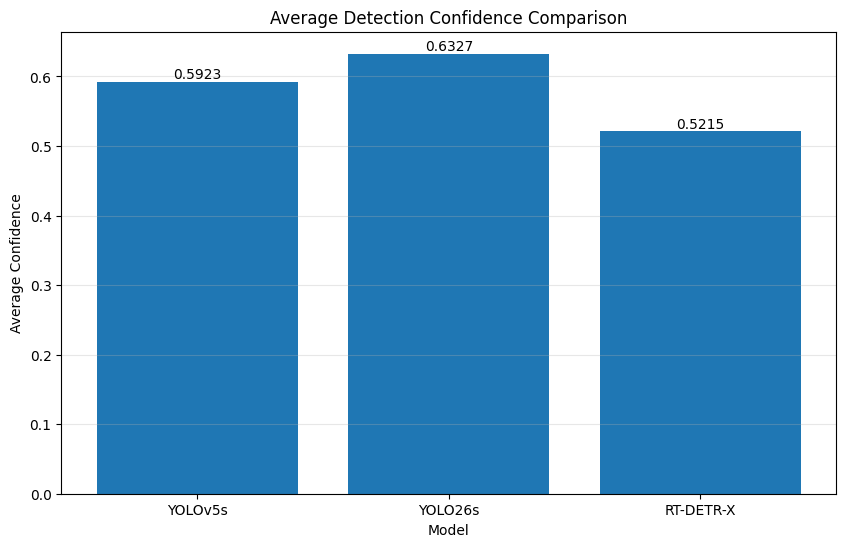


✓ MODEL COMPARISON VISUALIZATION COMPLETE


In [ ]:
# ============================================================
# CELL 15 — MODEL COMPARISON VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt


print("=" * 70)
print("MODEL COMPARISON VISUALIZATION")
print("=" * 70)


# ------------------------------------------------------------
# VERIFY AVAILABLE COLUMNS
# ------------------------------------------------------------

print("\nAvailable columns:")
print(list(comparison_df.columns))


# ------------------------------------------------------------
# CORRECT COLUMN NAMES
# ------------------------------------------------------------

MODEL_COLUMN = "Model"

COVERAGE_COLUMN = "Detection Coverage (%)"

DETECTIONS_COLUMN = (
    "Average Detections Per Image"
)

CONFIDENCE_COLUMN = (
    "Average Confidence"
)


# ------------------------------------------------------------
# VERIFY REQUIRED COLUMNS
# ------------------------------------------------------------

required_columns = [

    MODEL_COLUMN,

    COVERAGE_COLUMN,

    DETECTIONS_COLUMN,

    CONFIDENCE_COLUMN
]


for column in required_columns:

    assert column in comparison_df.columns, (
        f"Required column not found: {column}"
    )


# ------------------------------------------------------------
# SORT BY MODEL NAME
# ------------------------------------------------------------

plot_df = comparison_df.copy()


# ------------------------------------------------------------
# CHART 1 — DETECTION COVERAGE
# ------------------------------------------------------------

plt.figure(
    figsize=(10, 6)
)


plt.bar(
    plot_df[MODEL_COLUMN],
    plot_df[COVERAGE_COLUMN]
)


plt.title(
    "Detection Coverage Comparison"
)


plt.xlabel(
    "Model"
)


plt.ylabel(
    "Detection Coverage (%)"
)


plt.ylim(
    95,
    100.1
)


for i, value in enumerate(
    plot_df[COVERAGE_COLUMN]
):

    plt.text(
        i,
        value,
        f"{value:.4f}%",
        ha="center",
        va="bottom"
    )


plt.grid(
    axis="y",
    alpha=0.3
)


plt.show()


# ------------------------------------------------------------
# CHART 2 — AVERAGE DETECTIONS PER IMAGE
# ------------------------------------------------------------

plt.figure(
    figsize=(10, 6)
)


plt.bar(
    plot_df[MODEL_COLUMN],
    plot_df[DETECTIONS_COLUMN]
)


plt.title(
    "Average Object Detections Per Image"
)


plt.xlabel(
    "Model"
)


plt.ylabel(
    "Average Detections Per Image"
)


for i, value in enumerate(
    plot_df[DETECTIONS_COLUMN]
):

    plt.text(
        i,
        value,
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )


plt.grid(
    axis="y",
    alpha=0.3
)


plt.show()


# ------------------------------------------------------------
# CHART 3 — AVERAGE CONFIDENCE
# ------------------------------------------------------------

plt.figure(
    figsize=(10, 6)
)


plt.bar(
    plot_df[MODEL_COLUMN],
    plot_df[CONFIDENCE_COLUMN]
)


plt.title(
    "Average Detection Confidence Comparison"
)


plt.xlabel(
    "Model"
)


plt.ylabel(
    "Average Confidence"
)


for i, value in enumerate(
    plot_df[CONFIDENCE_COLUMN]
):

    plt.text(
        i,
        value,
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )


plt.grid(
    axis="y",
    alpha=0.3
)


plt.show()


print("\n" + "=" * 70)
print("✓ MODEL COMPARISON VISUALIZATION COMPLETE")
print("=" * 70)

AVERAGE DETECTION RICHNESS


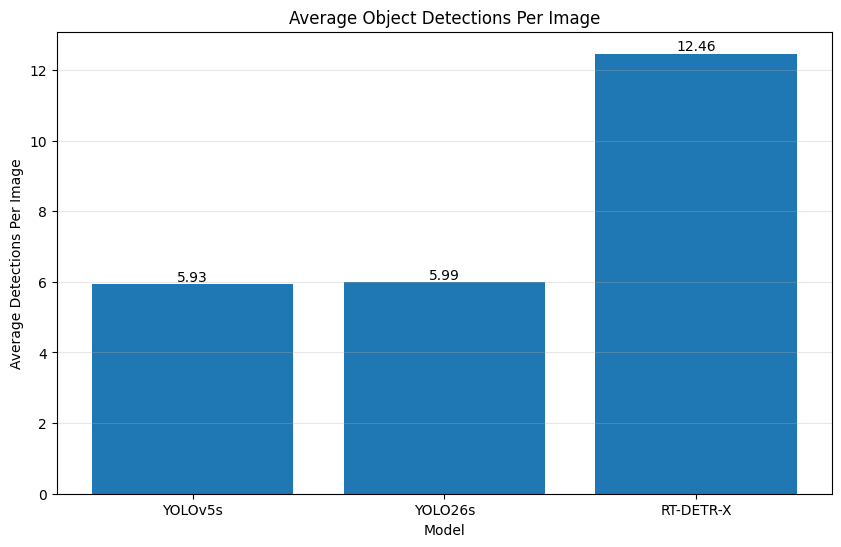


✓ Detection richness visualization complete


In [ ]:
# ============================================================
# CELL 16 — VISUALIZATION
# DETECTION RICHNESS
# ============================================================

import matplotlib.pyplot as plt


print("=" * 70)
print("AVERAGE DETECTION RICHNESS")
print("=" * 70)


plt.figure(
    figsize=(10, 6)
)


plt.bar(
    comparison_df["Model"],
    comparison_df[
        "Average Detections Per Image"
    ]
)


plt.title(
    "Average Object Detections Per Image"
)


plt.xlabel(
    "Model"
)


plt.ylabel(
    "Average Detections Per Image"
)


for i, value in enumerate(
    comparison_df[
        "Average Detections Per Image"
    ]
):

    plt.text(
        i,
        value,
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )


plt.grid(
    axis="y",
    alpha=0.3
)


plt.show()


print(
    "\n✓ Detection richness visualization complete"
)

OBJECT CLASS DIVERSITY VISUALIZATION


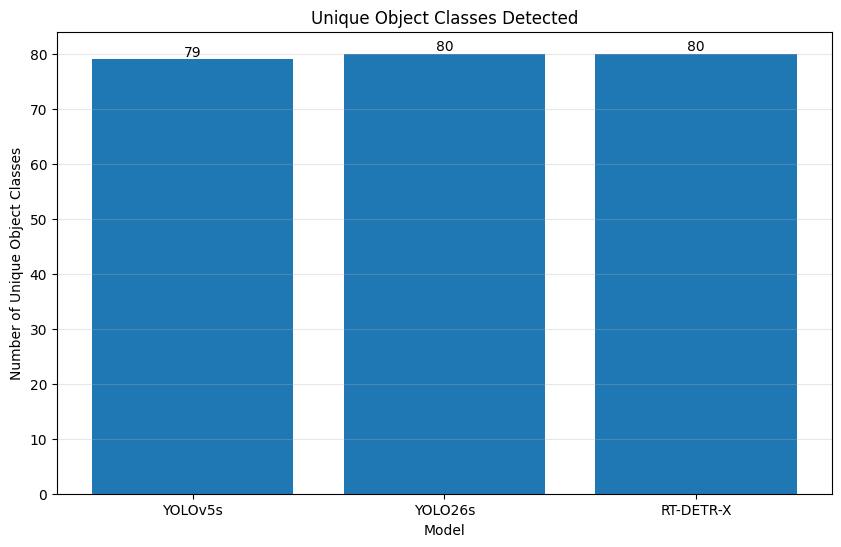


✓ Object class diversity visualization complete


In [ ]:
# ============================================================
# CELL 17 — VISUALIZATION
# OBJECT CLASS DIVERSITY
# ============================================================

import matplotlib.pyplot as plt


print("=" * 70)
print("OBJECT CLASS DIVERSITY VISUALIZATION")
print("=" * 70)


plt.figure(
    figsize=(10, 6)
)


plt.bar(
    comparison_df["Model"],
    comparison_df[
        "Unique Object Classes"
    ]
)


plt.title(
    "Unique Object Classes Detected"
)


plt.xlabel(
    "Model"
)


plt.ylabel(
    "Number of Unique Object Classes"
)


for i, value in enumerate(
    comparison_df[
        "Unique Object Classes"
    ]
):

    plt.text(
        i,
        value,
        str(int(value)),
        ha="center",
        va="bottom"
    )


plt.grid(
    axis="y",
    alpha=0.3
)


plt.show()


print(
    "\n✓ Object class diversity visualization complete"
)

TOTAL DETECTION RECORDS VISUALIZATION


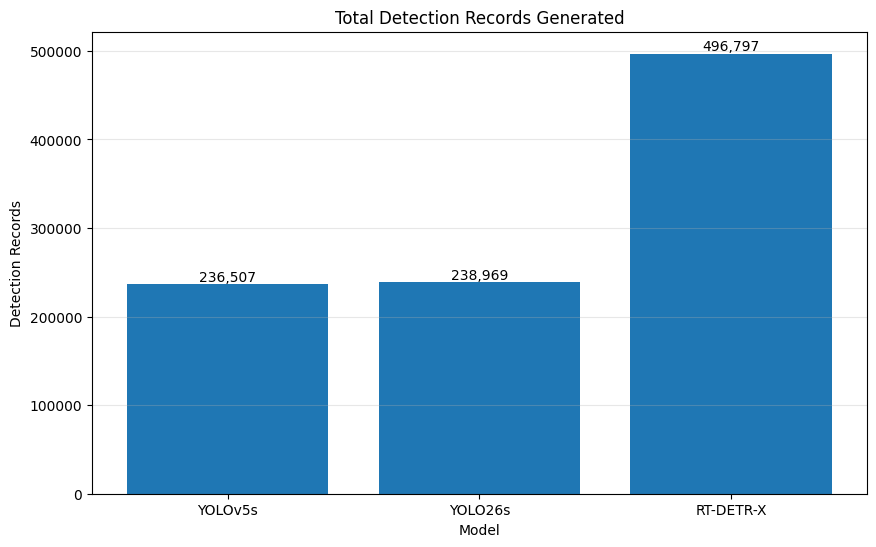


✓ Total detection records visualization complete


In [ ]:
# ============================================================
# CELL 18 — VISUALIZATION
# TOTAL DETECTION RECORDS
# ============================================================

import matplotlib.pyplot as plt


print("=" * 70)
print("TOTAL DETECTION RECORDS VISUALIZATION")
print("=" * 70)


plt.figure(
    figsize=(10, 6)
)


plt.bar(
    comparison_df["Model"],
    comparison_df[
        "Total Detection Records"
    ]
)


plt.title(
    "Total Detection Records Generated"
)


plt.xlabel(
    "Model"
)


plt.ylabel(
    "Detection Records"
)


for i, value in enumerate(
    comparison_df[
        "Total Detection Records"
    ]
):

    plt.text(
        i,
        value,
        f"{int(value):,}",
        ha="center",
        va="bottom"
    )


plt.grid(
    axis="y",
    alpha=0.3
)


plt.show()


print(
    "\n✓ Total detection records visualization complete"
)

In [ ]:
# ============================================================
# CELL 19 — SAVE COMPLETE COMPARISON REPORT
# ============================================================

import json


print("=" * 70)
print("CREATING FINAL COMPARISON REPORT")
print("=" * 70)


FINAL_REPORT = {


    "project":
        "Image Captioning — Object Detection Model Comparison",


    "total_dataset_images":
        int(TOTAL_IMAGES),


    "models_compared": [
        "YOLOv5s",
        "YOLO26s",
        "RT-DETR-X"
    ],


    "comparison_metrics": {


        "detection_coverage": (
            comparison_df[
                [
                    "Model",
                    "Detection Coverage (%)"
                ]
            ]
            .to_dict(
                orient="records"
            )
        ),


        "zero_detection_images": (
            comparison_df[
                [
                    "Model",
                    "Zero Detection Images"
                ]
            ]
            .to_dict(
                orient="records"
            )
        ),


        "total_detection_records": (
            comparison_df[
                [
                    "Model",
                    "Total Detection Records"
                ]
            ]
            .to_dict(
                orient="records"
            )
        ),


        "average_detections_per_image": (
            comparison_df[
                [
                    "Model",
                    "Average Detections Per Image"
                ]
            ]
            .to_dict(
                orient="records"
            )
        ),


        "average_confidence": (
            comparison_df[
                [
                    "Model",
                    "Average Confidence"
                ]
            ]
            .to_dict(
                orient="records"
            )
        ),


        "unique_object_classes": (
            comparison_df[
                [
                    "Model",
                    "Unique Object Classes"
                ]
            ]
            .to_dict(
                orient="records"
            )
        )

    },


    "experimental_ranking": (
        ranking_df
        .to_dict(
            orient="records"
        )
    )

}


# ------------------------------------------------------------
# SAVE REPORT
# ------------------------------------------------------------

REPORT_FILE = (
    OUTPUT_DIR
    / "model_comparison_report.json"
)


with open(
    REPORT_FILE,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        FINAL_REPORT,
        file,
        indent=4,
        default=str
    )


print(
    "\nFinal report saved:"
)


print(
    REPORT_FILE
)


print(
    "\n✓ REPORT SAVED SUCCESSFULLY"
)

CREATING FINAL COMPARISON REPORT

Final report saved:
/content/drive/MyDrive/Image_captioning/Outputs/Model_Comparison/model_comparison_report.json

✓ REPORT SAVED SUCCESSFULLY


In [ ]:
# ============================================================
# CELL 20 — FINAL VERIFICATION (CORRECTED)
# ============================================================

print("=" * 70)
print("NOTEBOOK 9 — FINAL VERIFICATION")
print("=" * 70)


# ------------------------------------------------------------
# MODELS
# ------------------------------------------------------------

print("\nMODELS COMPARED:")

for model in MODEL_DATA.keys():
    print(f"✓ {model}")


# ------------------------------------------------------------
# TOTAL IMAGES
# ------------------------------------------------------------

print("\nTOTAL DATASET IMAGES:")
print(TOTAL_IMAGES)


assert TOTAL_IMAGES == 39874, (
    f"Expected 39,874 images, found {TOTAL_IMAGES}"
)


# ------------------------------------------------------------
# CORE COMPARISON
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL MODEL COMPARISON")
print("=" * 70)

display(comparison_df)


# ------------------------------------------------------------
# EXPERIMENTAL RANKING
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("EXPERIMENTAL RANKING")
print("=" * 70)

display(ranking_df)


# ------------------------------------------------------------
# OUTPUT FILE CHECK
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("AVAILABLE OUTPUT FILES")
print("=" * 70)


# Only check variables/files that actually exist
output_variable_names = [

    "CORE_COMPARISON_FILE",

    "DETECTION_DISTRIBUTION_FILE",

    "CLASS_COMPARISON_FILE",

    "AGREEMENT_FILE",

    "CAPTION_FEATURE_FILE",

    "FINAL_RANKING_FILE",

    "REPORT_FILE"
]


files_found = 0


for variable_name in output_variable_names:

    if variable_name in globals():

        file_path = globals()[variable_name]

        print(f"\n✓ Variable: {variable_name}")
        print(f"  File: {file_path.name}")
        print(f"  Exists: {file_path.exists()}")

        files_found += 1

    else:

        print(f"\n- {variable_name}: Not created in this notebook version")


# ------------------------------------------------------------
# REQUIRED FILE VERIFICATION
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("REQUIRED RESULTS VERIFICATION")
print("=" * 70)


assert "comparison_df" in globals(), (
    "comparison_df is missing"
)


assert "ranking_df" in globals(), (
    "ranking_df is missing"
)


assert len(comparison_df) == 3, (
    "Expected exactly 3 models"
)


assert len(ranking_df) == 3, (
    "Expected ranking for exactly 3 models"
)


assert comparison_df["Model"].nunique() == 3, (
    "Expected 3 unique models"
)


print("\n✓ comparison_df exists")
print("✓ ranking_df exists")
print("✓ 3 models compared")
print("✓ 39,874 images verified")
print("✓ Experimental ranking generated")


# ------------------------------------------------------------
# DISPLAY WINNER
# ------------------------------------------------------------

winner = ranking_df.iloc[0]


print("\n" + "=" * 70)
print("EXPERIMENTAL COMPARISON RESULT")
print("=" * 70)


print(
    f"\nTop ranked model: "
    f"{winner['Model']}"
)


print(
    f"Final rank: "
    f"{winner['Final Rank']}"
)


print(
    f"Average rank score: "
    f"{winner['Average Rank Score']:.4f}"
)


# ------------------------------------------------------------
# FINAL STATUS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("✓ NOTEBOOK 9 COMPLETE")
print("=" * 70)


print("\nComparison output directory:")
print(OUTPUT_DIR)


print(
    "\nNOTE:"
)


print(
    "This comparison evaluates detection coverage, "
    "semantic richness, object diversity, and "
    "experimental ranking characteristics."
)


print(
    "\nIt does NOT represent official detection accuracy "
    "such as mAP, Precision, or Recall because this "
    "experiment did not use bounding-box ground truth."
)


print(
    "\nNEXT STAGE:"
)


print(
    "Use the selected object-detection features "
    "for the Image Caption Generation NLP pipeline."
)

NOTEBOOK 9 — FINAL VERIFICATION

MODELS COMPARED:
✓ YOLOv5s
✓ YOLO26s
✓ RT-DETR-X

TOTAL DATASET IMAGES:
39874

FINAL MODEL COMPARISON


,Model,Total Images,Images With Detections,Zero Detection Images,Detection Coverage (%),Zero Detection Rate (%),Total Detection Records,Average Detections Per Image,Average Confidence,Median Confidence,Unique Object Classes
0,YOLOv5s,39874,39633,241,99.3956,0.6044,236507,5.9314,0.5923,0.5968,79
1,YOLO26s,39874,39795,79,99.8019,0.1981,238969,5.9931,0.6327,0.6592,80
2,RT-DETR-X,39874,39868,6,99.9850,0.0150,496797,12.4592,0.5215,0.4231,80



EXPERIMENTAL RANKING


,Model,Final Rank,Total Images,Images With Detections,Zero Detection Images,Detection Coverage (%),Zero Detection Rate (%),Total Detection Records,Average Detections Per Image,Average Confidence,Median Confidence,Unique Object Classes,Coverage Rank,Object Class Rank,Detection Richness Rank,Average Rank Score
0,RT-DETR-X,1,39874,39868,6,99.9850,0.0150,496797,12.4592,0.5215,0.4231,80,1.0,1.0,1.0,1.000000
1,YOLO26s,2,39874,39795,79,99.8019,0.1981,238969,5.9931,0.6327,0.6592,80,2.0,1.0,2.0,1.666667
2,YOLOv5s,3,39874,39633,241,99.3956,0.6044,236507,5.9314,0.5923,0.5968,79,3.0,3.0,3.0,3.000000



AVAILABLE OUTPUT FILES

✓ Variable: CORE_COMPARISON_FILE
  File: object_detection_model_comparison.csv
  Exists: True

- DETECTION_DISTRIBUTION_FILE: Not created in this notebook version

✓ Variable: CLASS_COMPARISON_FILE
  File: object_class_availability_comparison.csv
  Exists: True

- AGREEMENT_FILE: Not created in this notebook version

✓ Variable: CAPTION_FEATURE_FILE
  File: captioning_object_feature_richness.csv
  Exists: True

✓ Variable: FINAL_RANKING_FILE
  File: experimental_model_ranking.csv
  Exists: True

✓ Variable: REPORT_FILE
  File: model_comparison_report.json
  Exists: True

REQUIRED RESULTS VERIFICATION

✓ comparison_df exists
✓ ranking_df exists
✓ 3 models compared
✓ 39,874 images verified
✓ Experimental ranking generated

EXPERIMENTAL COMPARISON RESULT

Top ranked model: RT-DETR-X
Final rank: 1
Average rank score: 1.0000

✓ NOTEBOOK 9 COMPLETE

Comparison output directory:
/content/drive/MyDrive/Image_captioning/Outputs/Model_Comparison

NOTE:
This comparison ev